# U-Net

## Configurations

In [ ]:
# Mount Google Drive to access the data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install necessary libraries
!pip install rasterio torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 55.7 MB/s eta 0:00:00


In [ ]:
import os
import tarfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from glob import glob
import rasterio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F
from torchmetrics import R2Score

In [ ]:
VERSION = '10'

In [ ]:
class Config:

    ########### ADJUSTABLE PARAMETERS #############
    VANILLA_MODEL = True

    USE_STANDARDIZATION = False    # Set to True to use Z-score normalization, False to skip it.

    USE_WEIGHTED_LOSS = False      # Set to True to use weighted loss, False to skip it.
    LOSS_RANGE_MIN = 5.0     # The lower bound of the AGB range to penalize more heavily.
    LOSS_RANGE_MAX = 300.0   # The upper bound of the AGB range to penalize more heavily.
    WEIGHT_LOSS_FACTOR = 1.5   # The multiplication factor for the loss on pixels within the specified range.

    USE_IGNORE_HIGH_VALUES = False
    LOSS_IGNORE_THRESHOLD = 400.0

    #DATA_AUGMENTATION = None      # to be implemented

    #LOSS_PERCENTILE = 99.0
    #LP1= str(LOSS_PERCENTILE).split('.')[0]
    #LP2 = str(LOSS_PERCENTILE).split('.')[1]

    # Training parameters
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_EPOCHS = 100
    BATCH_SIZE = 1
    LEARNING_RATE = 1e-4
    #WEIGHT_DECAY = 1e-5
    WEIGHT_DECAY = 0 # Weight decay deactivated
    NUM_WORKERS = 4 # Colab usually has 2 CPU cores
    PIN_MEMORY = True
    SEED = 42
    PLOT_SAMPLE_SIZE = 18_200_000

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # Model Name Definition
    LF1 = str(WEIGHT_LOSS_FACTOR).split('.')[0]
    LF2 = str(WEIGHT_LOSS_FACTOR).split('.')[1]

    if VANILLA_MODEL:
      MODEL_NAME = f"UNet_baseline_full_dataset_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}"
    else:
      if USE_WEIGHTED_LOSS:
        MODEL_NAME = f"UNet_baseline_full_dataset_WLR{LOSS_RANGE_MIN}-{LOSS_RANGE_MAX}_WLF{LF1}.{LF2}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}"
      else:
        MODEL_NAME = f"UNet_baseline_full_dataset_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}"

    if USE_IGNORE_HIGH_VALUES:
      MODEL_NAME = MODEL_NAME + f"_IgnHi{int(LOSS_IGNORE_THRESHOLD)}"

    if USE_STANDARDIZATION:
      MODEL_NAME = MODEL_NAME + "_Stand"

    MODEL_NAME = MODEL_NAME + f"_Seed{SEED}"

    #MODEL_NAME = f"UNet_v{VERSION}_PERC{LP1}-{LP2}_LF{LF1}-{LF2}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_WDC{f"{WEIGHT_DECAY:5f}".split('.')[1][:5]}_SEED{SEED}"
    #MODEL_NAME = f"UNet_v{VERSION}_EP{NUM_EPOCHS}_BS{BATCH_SIZE}_LR{str(LEARNING_RATE).split('.')[1]}_WDC{f"{WEIGHT_DECAY:5f}".split('.')[1][:5]}"
    print(MODEL_NAME)
    OUTPUT_DIR = os.path.join(f"/content/drive/MyDrive/master_thesis_FM/experiments/baseline_UNet_raw_s1/", MODEL_NAME)
    STATS_FILE = os.path.join(OUTPUT_DIR, "norm_stats.pt")


    ########### PATH DEFINITIONS #############
    DRIVE_BASE_PATH = "/content/drive/MyDrive/master_thesis_FM/datasets/BioMassters/packed_compressed_data/tar_gz_archives" # Data paths on Google Drive
    FEATURES_TRAIN = "s1_data/orig_train.tar.gz"
    FEATURES_TEST = "s1_data/orig_test.tar.gz"
    LABELS_TRAIN = "labels/train_agbm.tar.gz"
    LABELS_TEST = "labels/test_agbm.tar.gz"

    # Input data archives
    S1_TRAIN_ARCHIVE = os.path.join(DRIVE_BASE_PATH, FEATURES_TRAIN)
    S1_TEST_ARCHIVE = os.path.join(DRIVE_BASE_PATH, FEATURES_TEST)

    # Label data archives
    AGB_TRAIN_ARCHIVE = os.path.join(DRIVE_BASE_PATH, LABELS_TRAIN)
    AGB_TEST_ARCHIVE = os.path.join(DRIVE_BASE_PATH, LABELS_TEST)

    # Local Colab paths for extracted data
    LOCAL_DATA_PATH = "/content/data"
    S1_TRAIN_PATH = os.path.join(LOCAL_DATA_PATH, "s1_train")
    S1_TEST_PATH = os.path.join(LOCAL_DATA_PATH, "s1_test")
    AGB_TRAIN_PATH = os.path.join(LOCAL_DATA_PATH, "agb_train")
    AGB_TEST_PATH = os.path.join(LOCAL_DATA_PATH, "agb_test")


# Create the config object and output directory
config = Config()

if os.path.isdir(config.OUTPUT_DIR):
  print("Output directory exists!")


print(f"Using device: {config.DEVICE}")
if config.DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

UNet_v10_WLR5.0-300.0_WLF1.5_EP50_BS16_LR0001_IgnHi400_Seed42
Using device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
os.makedirs(config.OUTPUT_DIR, exist_ok=False)

### Clearing CUDA cache from previous runs to release all available GPU memory capacity

In [ ]:
import torch
import gc

# Run Python's garbage collector
gc.collect()

# Tell PyTorch to release the cached memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("PyTorch CUDA cache has been cleared.")

# You can now re-run the GPU Analysis cell to confirm the memory has been freed.

PyTorch CUDA cache has been cleared.


In [ ]:
import torch

# This cell analyzes the available GPU hardware.
if torch.cuda.is_available():
    # Get the current device ID
    device_id = torch.cuda.current_device()

    # Get the device properties
    gpu_properties = torch.cuda.get_device_properties(device_id)
    gpu_name = gpu_properties.name
    total_vram_gb = gpu_properties.total_memory / (1024**3)

    # Get the currently free memory, which is a better indicator of what's usable
    # This accounts for memory already used by the CUDA context, etc.
    free_vram_bytes, _ = torch.cuda.mem_get_info(device_id)
    available_vram_gb = free_vram_bytes / (1024**3)

    # Define a safety margin (e.g., use 90% of available VRAM) to prevent crashes
    usable_vram_gb = available_vram_gb * 0.90

    print("--- GPU Analysis ---")
    print(f"✅ Detected GPU: {gpu_name}")
    print(f"   - Total VRAM:      {total_vram_gb:.2f} GB")
    print(f"   - Available VRAM:  {available_vram_gb:.2f} GB")
    print(f"   - Usable (w/ 90% safety margin): {usable_vram_gb:.2f} GB")
    print("--------------------")

else:
    gpu_name = "N/A"
    usable_vram_gb = 0
    print("❌ No GPU detected. The model will run on the CPU.")

--- GPU Analysis ---
✅ Detected GPU: NVIDIA L4
   - Total VRAM:      22.16 GB
   - Available VRAM:  21.65 GB
   - Usable (w/ 90% safety margin): 19.49 GB
--------------------


# Definitions & helper functions

In [ ]:
def seed_everything(seed: int):
    """
    Sets the seed for all relevant random number generators to ensure reproducibility.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if you are using multi-GPU.
    # The two lines below are known to be necessary for full reproducibility
    # with CUDA, but they can slow down training.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to {seed}")

# Set the seed for the entire session
seed_everything(config.SEED)

Global seed set to 42


In [ ]:
def extract_tar_gz(tar_path, extract_path):
    """Helper function to extract a .tar.gz archive."""
    print(f"Extracting {os.path.basename(tar_path)} to {extract_path}...")
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete.")

# --- Main Logic: Check if data is already extracted in this session ---
# We check for the existence of the final directories in Colab's local storage.
if os.path.exists(config.S1_TRAIN_PATH) and len(os.listdir(config.S1_TRAIN_PATH)) > 0:
    print("Data directories already exist and are not empty in Colab's local storage.")
    print(f"Found {len(os.listdir(config.S1_TRAIN_PATH))} files in {os.path.basename(config.S1_TRAIN_PATH)}")
    print(f"Found {len(os.listdir(config.S1_TEST_PATH))} files in {os.path.basename(config.S1_TEST_PATH)}")
    print("Skipping copy and extraction.")
else:
    print("Data not found in local storage. Starting copy and extraction process...")

    # Copy and extract training data
    print("--- Preparing Training Data ---")
    !cp "{config.S1_TRAIN_ARCHIVE}" .
    !cp "{config.AGB_TRAIN_ARCHIVE}" .
    extract_tar_gz(config.FEATURES_TRAIN, config.S1_TRAIN_PATH)
    extract_tar_gz(config.LABELS_TRAIN, config.AGB_TRAIN_PATH)

    # Copy and extract test/validation data
    print("\n--- Preparing Test/Validation Data ---")
    !cp "{config.S1_TEST_ARCHIVE}" .
    !cp "{config.AGB_TEST_ARCHIVE}" .
    extract_tar_gz(config.FEATURES_TEST, config.S1_TEST_PATH)
    extract_tar_gz(config.LABELS_TEST, config.AGB_TEST_PATH)

    # --- Clean up local archives to save space ---
    !rm *.tar.gz
    print("\nData preparation complete.")

Data not found in local storage. Starting copy and extraction process...
--- Preparing Training Data ---
Extracting S1_July_train_features.tar.gz to /content/data/s1_train...


/tmp/ipython-input-2269733273.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete.
Extracting train_agbm.tar.gz to /content/data/agb_train...
Extraction complete.

--- Preparing Test/Validation Data ---
Extracting S1_July_test_features.tar.gz to /content/data/s1_test...
Extraction complete.
Extracting test_agbm.tar.gz to /content/data/agb_test...
Extraction complete.

Data preparation complete.


In [ ]:
from sklearn.model_selection import train_test_split
import random

# --- This cell prepares the file lists for training, validation, and testing ---

# 1. Find all file pairs in the original training directory
print("Creating file lists...")
s1_train_files_all = sorted(glob(os.path.join(config.S1_TRAIN_PATH, "*_S1_10.tif")))
agb_files_all = {os.path.basename(f).split('_')[0]: f for f in glob(os.path.join(config.AGB_TRAIN_PATH, "*_agbm.tif"))}

all_train_val_pairs = []
for s1_file in s1_train_files_all:
    s1_id = os.path.basename(s1_file).split('_')[0]
    if s1_id in agb_files_all:
        all_train_val_pairs.append((s1_file, agb_files_all[s1_id]))

# 2. Shuffle and split the list into new training and validation sets
random.seed(config.SEED) # Use the global seed for a reproducible split
random.shuffle(all_train_val_pairs)

split_ratio = 0.8
split_index = int(len(all_train_val_pairs) * split_ratio)

train_file_pairs = all_train_val_pairs[:split_index]
val_file_pairs = all_train_val_pairs[split_index:]

print(f"Total samples for Train/Val: {len(all_train_val_pairs)}")
print(f"--> Training samples:   {len(train_file_pairs)}")
print(f"--> Validation samples: {len(val_file_pairs)}")

# 3. Create the file list for the final, held-out test set
s1_test_files = sorted(glob(os.path.join(config.S1_TEST_PATH, "*_S1_10.tif")))
agb_test_files_map = {os.path.basename(f).split('_')[0]: f for f in glob(os.path.join(config.AGB_TEST_PATH, "*_agbm.tif"))}
test_file_pairs = []
for s1_file in s1_test_files:
    s1_id = os.path.basename(s1_file).split('_')[0]
    if s1_id in agb_test_files_map:
        test_file_pairs.append((s1_file, agb_test_files_map[s1_id]))

print(f"--> Inference Test samples: {len(test_file_pairs)}")

Creating file lists...
Total samples for Train/Val: 8689
--> Training samples:   6951
--> Validation samples: 1738
--> Inference Test samples: 2773


In [ ]:
class AGB_Dataset(Dataset):

    def __init__(self, file_pairs, transform=None):
        self.file_pairs = file_pairs
        self.transform = transform
        print(f"Initialized dataset with {len(self.file_pairs)} samples.")

    def __len__(self):
        return len(self.file_pairs)

    def __getitem__(self, idx):
        s1_path, agb_path = self.file_pairs[idx]

        # Read Sentinel-1 SAR data (first two bands)
        with rasterio.open(s1_path) as src:
            s1_image = src.read([1, 2]).astype(np.float32)

        # Read AGB label data
        with rasterio.open(agb_path) as src:
            agb_image = src.read(1).astype(np.float32)
            agb_image = np.expand_dims(agb_image, axis=0)

        s1_tensor = torch.from_numpy(s1_image)
        agb_tensor = torch.from_numpy(agb_image)

        if self.transform:
            stacked = torch.cat((s1_tensor, agb_tensor), dim=0)
            stacked = self.transform(stacked)
            s1_tensor = stacked[:2, :, :]
            agb_tensor = stacked[2:, :, :]

        return s1_tensor, agb_tensor

# Define on-the-fly transformations for training data (augmentation)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

In [ ]:
# calculates z-score standardization stats
def get_normalization_stats(dataloader):
    print("Calculating normalization statistics from the training set...")
    channels_sum, channels_squared_sum, num_batches = 0, 0, 0

    for data, _ in tqdm(dataloader):
        # data shape is [B, C, H, W]
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_squared_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    mean = channels_sum / num_batches
    std = (channels_squared_sum / num_batches - mean**2)**0.5

    return mean, std

# --- Main Logic: Load if exists, otherwise calculate and save ---
if os.path.exists(config.STATS_FILE):
    print(f"Loading normalization statistics from {config.STATS_FILE}...")
    stats = torch.load(config.STATS_FILE)
    S1_MEAN = stats['mean']
    S1_STD = stats['std']
    print("Statistics loaded successfully.")
else:
    print(f"Statistics file not found at {config.STATS_FILE}. Calculating from scratch...")

    # Create a temporary dataset and dataloader JUST for calculating stats
    try:
        temp_train_dataset = AGB_Dataset(file_pairs=train_file_pairs)
    except NameError:
        print("ERROR: 'train_file_pairs' is not defined. Please run the 'Data Splitting' cell first.")
        raise

    temp_train_loader = DataLoader(
        temp_train_dataset,
        batch_size=config.BATCH_SIZE,
        num_workers=config.NUM_WORKERS
    )

    # Calculate stats
    S1_MEAN, S1_STD = get_normalization_stats(temp_train_loader)

    # Save the calculated stats to Google Drive for future use
    print(f"Saving normalization statistics to {config.STATS_FILE}...")
    torch.save({'mean': S1_MEAN, 'std': S1_STD}, config.STATS_FILE)
    print("Statistics saved for future sessions.")

# Finally, move the loaded or calculated stats to the correct device
S1_MEAN = S1_MEAN.to(config.DEVICE)
S1_STD = S1_STD.to(config.DEVICE)

print(f"\nUsing Mean: {S1_MEAN.cpu().numpy()}")
print(f"Using Std: {S1_STD.cpu().numpy()}")

Loading normalization statistics from /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/norm_stats.pt...
Statistics loaded successfully.

Using Mean: [-10.961649 -17.099825]
Using Std: [3.3200552 4.4785457]


In [ ]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        # --- ENCODER (Downsampling) ---
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # --- BOTTLENECK ---
        self.bottleneck = DoubleConv(512, 1024)
        # Modification 2: Dropout (p=0.5) added to the bottleneck
        self.dropout = nn.Dropout(p=0.5)

        # --- DECODER (Upsampling) ---
        # Modification 3 & 4 & 5: Hardcoded ConvTranspose2d, no dynamic padding blocks
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up4 = DoubleConv(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = DoubleConv(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = DoubleConv(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up1 = DoubleConv(128, 64)

        # --- FINAL OUTPUT ---
        # Modification 1: Output clamped using ReLU
        self.outc = nn.Sequential(
            nn.Conv2d(64, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        # Encoder Path
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.down3(self.pool2(x2))
        x4 = self.down4(self.pool3(x3))

        # Bottleneck Path
        x5 = self.bottleneck(self.pool4(x4))
        x5 = self.dropout(x5) # Applying dropout

        # Decoder Path with skip connections (Concatenation over channel dim)
        x = self.upconv4(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.up4(x)

        x = self.upconv3(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up3(x)

        x = self.upconv2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)

        x = self.upconv1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x)

        # Output Path
        return self.outc(x)

In [ ]:
class FlexibleMSELoss(nn.Module):
    """
    A unified MSE Loss that supports:
    1. Standard MSE (all weights = 1)
    2. Weighted MSE (specific range gets higher weights)
    3. Masked MSE (specific range is ignored/weight=0)
    """
    def __init__(self,
                 use_weighting=False,
                 weight_min=0, weight_max=0, high_weight=1.0,
                 use_ignore=False,
                 ignore_threshold=0):
        super().__init__()
        self.use_weighting = use_weighting
        self.min_val = weight_min
        self.max_val = weight_max
        self.high_weight = high_weight

        self.use_ignore = use_ignore
        self.ignore_threshold = ignore_threshold

        print("--- Loss Function Initialized ---")
        if self.use_weighting:
            print(f"✅ Weighting ENABLED: x {self.high_weight} for range [{self.min_val}, {self.max_val}]")
        else:
            print("🔹 Weighting DISABLED")

        if self.use_ignore:
            print(f"✅ Ignoring ENABLED: pixels > {self.ignore_threshold} contribute 0 loss")
        else:
            print("🔹 Ignoring DISABLED")

    def forward(self, predictions, targets):
        # 1. Calculate raw squared errors (element-wise)
        squared_errors = F.mse_loss(predictions, targets, reduction='none')

        # 2. Initialize weights (Default = 1.0)
        weights = torch.ones_like(targets)

        # 3. Apply Weighting (if enabled)
        if self.use_weighting:
            weight_mask = (targets >= self.min_val) & (targets <= self.max_val)
            weights[weight_mask] = self.high_weight

        # 4. Apply Ignoring (if enabled) -> This overwrites previous weights!
        # We set the weight to 0.0, effectively removing it from the loss.
        if self.use_ignore:
            ignore_mask = targets > self.ignore_threshold
            weights[ignore_mask] = 0.0

        # 5. Calculate Final Loss
        # We use a weighted average: Sum(Errors * Weights) / Sum(Weights)
        # This ensures the loss scale doesn't fluctuate wildly if we ignore many pixels.

        # Add a small epsilon to denominator to prevent division by zero if all pixels are ignored
        loss_sum = (squared_errors * weights).sum()
        weight_sum = weights.sum() + 1e-8

        return loss_sum / weight_sum

In [ ]:
# --- This cell sets up the Flexible Loss Function ---

# We pass ALL flags to the class, allowing it to decide what to do.
print("--- Setting up Flexible Loss Function ---")

loss_fn = FlexibleMSELoss(
    # Weighting Settings
    use_weighting=config.USE_WEIGHTED_LOSS,
    weight_min=config.LOSS_RANGE_MIN,
    weight_max=config.LOSS_RANGE_MAX,
    high_weight=config.WEIGHT_LOSS_FACTOR,

    # Ignore/Masking Settings
    use_ignore=config.USE_IGNORE_HIGH_VALUES,
    ignore_threshold=config.LOSS_IGNORE_THRESHOLD
)

# The 'loss_fn' variable is now defined and ready for the main training loop.

--- Setting up Flexible Loss Function ---
--- Loss Function Initialized ---
✅ Weighting ENABLED: x 1.5 for range [5.0, 300.0]
✅ Ignoring ENABLED: pixels > 400.0 contribute 0 loss


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics import R2Score
from tqdm.notebook import tqdm

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def train_fn(loader, model, optimizer, loss_fn, scaler, normalizer):
    loop = tqdm(loader, leave=True, desc="Training")
    running_loss = 0.0

    model.train()
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=config.DEVICE)
        targets = targets.to(device=config.DEVICE)

        data = normalizer(data)

        # Mixed Precision Training
        with torch.amp.autocast(device_type="cuda"): # Updated for new PyTorch
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader)

def validate_fn(loader, model, loss_fn, normalizer):
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in loader:
            data = data.to(device=config.DEVICE)
            targets = targets.to(device=config.DEVICE)
            data = normalizer(data)

            predictions = model(data)

            # 1. Calculate Loss (Respects Config settings automatically)
            loss = loss_fn(predictions, targets)
            val_loss += loss.item()

            # Flatten and collect
            all_preds.append(predictions.view(-1))
            all_targets.append(targets.view(-1))

    # Concatenate all batches
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # --- MODIFIED: Apply Masking to Metrics if Needed ---
    if config.USE_IGNORE_HIGH_VALUES:
        # Create a boolean mask of VALID pixels (<= threshold)
        valid_mask = all_targets <= config.LOSS_IGNORE_THRESHOLD

        # Filter the arrays to keep only valid pixels for metric calculation
        metric_preds = all_preds[valid_mask]
        metric_targets = all_targets[valid_mask]
    else:
        metric_preds = all_preds
        metric_targets = all_targets

    # --- Calculate Metrics on the (potentially filtered) data ---
    if len(metric_targets) > 0:
        mae = F.l1_loss(metric_preds, metric_targets).item()
        rmse = torch.sqrt(F.mse_loss(metric_preds, metric_targets)).item()

        r2_metric = R2Score().to(config.DEVICE)
        r2 = r2_metric(metric_preds, metric_targets).item()
    else:
        # Fallback if all pixels were ignored (unlikely)
        mae, rmse, r2 = 0.0, 0.0, 0.0

    avg_val_loss = val_loss / len(loader)

    print(f"Validation => Avg Loss: {avg_val_loss:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    return avg_val_loss, rmse, mae, r2

In [ ]:
# --- This cell is to use the new train/val/test splits ---

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# 1. Create the datasets using the pre-split file lists
train_dataset = AGB_Dataset(file_pairs=train_file_pairs, transform=None) # deactivated data augmentation
val_dataset = AGB_Dataset(file_pairs=val_file_pairs) # No transforms for validation
test_dataset = AGB_Dataset(file_pairs=test_file_pairs)   # No transforms for final testing

# 2. Create the DataLoaders
g = torch.Generator()
g.manual_seed(config.SEED)

train_loader = DataLoader(
    train_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=True, worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=False
)
# New loader for the final test set
test_loader = DataLoader(
    test_dataset, batch_size=config.BATCH_SIZE, num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY, shuffle=False
)

# The rest of the cell (model init, optimizer, training loop) remains the same
model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE) # Example with bilinear=False
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler()

# Creating the normalizer based on the Config setting
if config.USE_STANDARDIZATION:
    print("Standardization: ENABLED (using calculated stats)")
    # Standardization transform using calculated stats
    normalize_transform = transforms.Normalize(mean=S1_MEAN, std=S1_STD)
else:
    print("Standardization: DISABLED (using raw data)")
    # Use an "identity" transform that does nothing
    normalize_transform = nn.Identity()

best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')
early_stopper = EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE, verbose=True, path=best_model_path)
history = {'train_loss': [], 'val_loss': [], 'val_rmse': [], 'val_mae': [], 'val_r2': []}

Initialized dataset with 6951 samples.
Initialized dataset with 1738 samples.
Initialized dataset with 2773 samples.
Standardization: ENABLED (using calculated stats)


/tmp/ipython-input-1049847132.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


### Estimating max batch size

In [ ]:
import torch.nn.functional as F

def estimate_max_batch_size(model, optimizer, usable_vram_gb, input_shape=(2, 256, 256)):
    """
    Estimates the maximum possible batch size for a model given the available VRAM.
    This version uses a more robust heuristic without a fixed overhead assumption.
    """
    if config.DEVICE == 'cpu':
        print("Batch size estimation is not applicable for CPU.")
        return

    print("\n--- Max Batch Size Estimator (v3 - Corrected) ---")

    model.to(config.DEVICE)
    gb_divisor = 1024**3

    # 1. Calculate Static Memory (Model Parameters + Optimizer States)
    param_size_bytes = sum(p.numel() * 4 for p in model.parameters())
    optim_size_bytes = sum(p.numel() * 8 for p in model.parameters())
    static_memory_gb = (param_size_bytes + optim_size_bytes) / gb_divisor
    print(f"Estimated Static Memory (Model + Optimizer): {static_memory_gb:.3f} GB")

    # 2. Measure Dynamic Memory by running a test batch
    test_batch_size = 2
    dummy_input = torch.randn(test_batch_size, *input_shape, dtype=torch.float32).to(config.DEVICE)
    dummy_target = torch.randn(test_batch_size, 1, *input_shape[1:], dtype=torch.float32).to(config.DEVICE)
    torch.cuda.reset_peak_memory_stats()

    try:
        # Perform a full pass to get a realistic memory peak
        with torch.amp.autocast(device_type="cuda"):
            output = model(dummy_input)
            loss = F.mse_loss(output, dummy_target)

        # --- CORRECTED LINE ---
        # The GradScaler constructor does not take a 'device_type' argument.
        scaler = torch.amp.GradScaler()
        # --- END OF CORRECTION ---

        scaler.scale(loss).backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        peak_memory_gb = torch.cuda.max_memory_allocated() / gb_divisor

        dynamic_memory_gb = peak_memory_gb - static_memory_gb
        memory_per_sample_gb = dynamic_memory_gb / test_batch_size

        print(f"Peak memory for Batch Size={test_batch_size}: {peak_memory_gb:.3f} GB")
        print(f"Estimated Memory per Sample (Activations + Overhead): {memory_per_sample_gb:.3f} GB")

        # 3. Calculate and Recommend Max Batch Size
        vram_available_for_dynamic_mem = usable_vram_gb - static_memory_gb

        if vram_available_for_dynamic_mem > 0 and memory_per_sample_gb > 0:
            estimated_max_bs = int(vram_available_for_dynamic_mem / memory_per_sample_gb)
            print("\n---------------------------------------------------------")
            print(f"---> 💡 Estimated Max Batch Size: {estimated_max_bs} <---")
            print("---------------------------------------------------------")
        else:
            print("\n---> ⚠️ Could not estimate batch size. The static memory may be too high.")

    except RuntimeError as e:
        if "out of memory" in str(e):
            print("\n---> ❌ CUDA out of memory even with a small test batch.")
        else:
            raise e
    finally:
        del dummy_input, dummy_target
        torch.cuda.empty_cache()

# --- HOW TO USE IT ---
# Call this function after initializing your model and optimizer.
estimate_max_batch_size(model, optimizer, usable_vram_gb)


--- Max Batch Size Estimator (v3 - Corrected) ---
Estimated Static Memory (Model + Optimizer): 0.347 GB
Peak memory for Batch Size=2: 0.706 GB
Estimated Memory per Sample (Activations + Overhead): 0.179 GB

---------------------------------------------------------
---> 💡 Estimated Max Batch Size: 104 <---
---------------------------------------------------------


# TRAINING LOOP

In [ ]:
# --- TRAINING LOOP ---
for epoch in range(config.NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{config.NUM_EPOCHS} ---")

    train_loss = train_fn(train_loader, model, optimizer, loss_fn, scaler, normalize_transform)
    val_loss, val_rmse, val_mae, val_r2 = validate_fn(val_loader, model, loss_fn, normalize_transform)

    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_mae'].append(val_mae)
    history['val_r2'].append(val_r2)

    # Early stopping check
    early_stopper(val_loss, model)
    if early_stopper.early_stop:
        print("Early stopping triggered!")
        break


# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.OUTPUT_DIR, 'training_history.csv'), index=False)
print("\nTraining complete. Best model and history saved.")


--- Epoch 1/50 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

Validation => Avg Loss: 9008.7418, RMSE: 91.7364, MAE: 61.4924, R²: -0.7350
Validation loss decreased (inf --> 9008.741789). Saving model...

--- Epoch 2/50 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

Validation => Avg Loss: 1843.6377, RMSE: 42.0875, MAE: 26.2848, R²: 0.6348
EarlyStopping counter: 9 out of 10

--- Epoch 38/50 ---


Training:   0%|          | 0/435 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/l

Validation => Avg Loss: 1891.0640, RMSE: 42.6406, MAE: 26.7018, R²: 0.6252
EarlyStopping counter: 10 out of 10
Early stopping triggered!

Training complete. Best model and history saved.



# Plot of Training progress

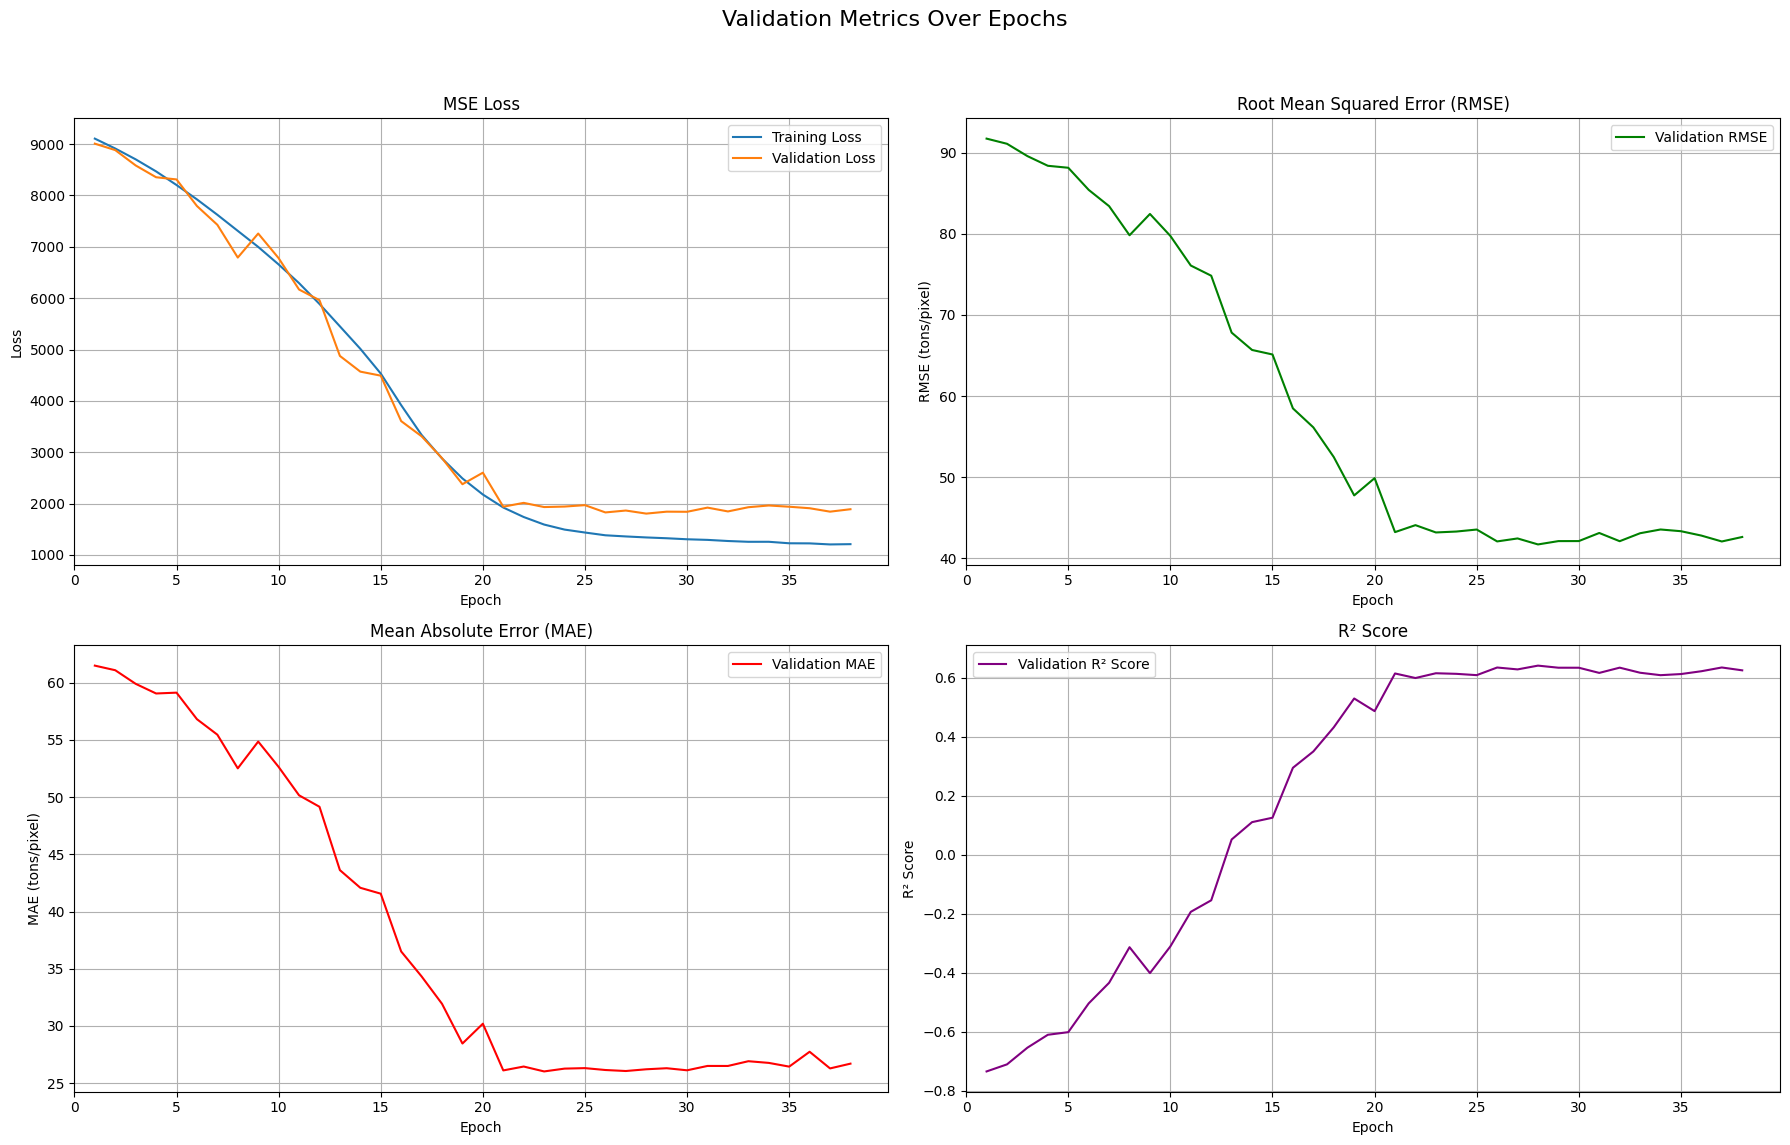

In [ ]:
# This cell is self-contained and works on any runtime

def plot_metrics_from_csv(history_path, output_path):
    """Loads history from a CSV file and plots the metrics with 1-based epoch numbering."""
    if not os.path.exists(history_path):
        print(f"Error: Training history file not found at {history_path}")
        return

    history_df = pd.read_csv(history_path)

    # Create a 1-based epoch count for the x-axis
    epochs = history_df.index + 1

    fig, axs = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Validation Metrics Over Epochs', fontsize=16)

    # Loss (MSE)
    axs[0, 0].plot(epochs, history_df['train_loss'], label='Training Loss')
    axs[0, 0].plot(epochs, history_df['val_loss'], label='Validation Loss')
    axs[0, 0].set_title('MSE Loss')
    axs[0, 0].set_xlabel('Epoch')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # RMSE
    axs[0, 1].plot(epochs, history_df['val_rmse'], label='Validation RMSE', color='green')
    axs[0, 1].set_title('Root Mean Squared Error (RMSE)')
    axs[0, 1].set_xlabel('Epoch')
    axs[0, 1].set_ylabel('RMSE (tons/pixel)')
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # MAE
    axs[1, 0].plot(epochs, history_df['val_mae'], label='Validation MAE', color='red')
    axs[1, 0].set_title('Mean Absolute Error (MAE)')
    axs[1, 0].set_xlabel('Epoch')
    axs[1, 0].set_ylabel('MAE (tons/pixel)')
    axs[1, 0].legend()
    axs[1, 0].grid(True)

    # R2 Score
    axs[1, 1].plot(epochs, history_df['val_r2'], label='Validation R² Score', color='purple')
    axs[1, 1].set_title('R² Score')
    axs[1, 1].set_xlabel('Epoch')
    axs[1, 1].set_ylabel('R² Score')
    axs[1, 1].legend()
    axs[1, 1].grid(True)

    # Set x-axis to start at 0 to include it as a tick mark ---
    if not history_df.empty:
        axs[0, 0].set_xlim(left=0)
        axs[0, 1].set_xlim(left=0)
        axs[1, 0].set_xlim(left=0)
        axs[1, 1].set_xlim(left=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(output_path)
    plt.show()

# --- Execution ---
history_csv_path = os.path.join(config.OUTPUT_DIR, 'training_history.csv')
metrics_plot_path = os.path.join(config.OUTPUT_DIR, 'training_metrics.png')
plot_metrics_from_csv(history_csv_path, metrics_plot_path)

# Best epoch + validation metrics

In [ ]:
import pandas as pd
import os

# --- This cell analyzes the training history to find the best epoch ---

# This assumes the 'config' object from Cell 2 is still available.
# It will work in either a CPU or GPU runtime.
try:
    history_csv_path = os.path.join(config.OUTPUT_DIR, 'training_history.csv')

    # Check if the history file actually exists
    if os.path.exists(history_csv_path):
        print(f"Analyzing training history from: {history_csv_path}\n")

        # Read the history file into a pandas DataFrame
        history_df = pd.read_csv(history_csv_path)

        # --- Find the epoch with the minimum validation loss ---
        # The .idxmin() function returns the index of the first occurrence of the minimum value.
        best_epoch_idx = history_df['val_loss'].idxmin()

        # Retrieve the entire row of metrics for that best epoch
        best_metrics_series = history_df.loc[best_epoch_idx]

        # --- Print the results in a clear, formatted report ---
        print("="*45)
        print("   🏆 Analysis of Best Model Performance 🏆")
        print("="*45)
        # Add 1 to the index because epochs are 1-based, while indices are 0-based.
        print(f"The best model was saved at Epoch: {best_epoch_idx + 1}")
        print("-" * 45)
        print("Metrics at this epoch:")
        print(f"  - Validation Loss (MSE): {best_metrics_series['val_loss']:.5f}")
        print(f"  - Validation RMSE:       {best_metrics_series['val_rmse']:.4f} tons/pixel")
        print(f"  - Validation MAE:        {best_metrics_series['val_mae']:.4f} tons/pixel")
        print(f"  - Validation R² Score:   {best_metrics_series['val_r2']:.4f}")
        print("="*45)

    else:
        print(f"❌ Error: The training history file was not found at '{history_csv_path}'.")
        print("Please ensure that a training run has completed and saved the file.")

except NameError:
    print("❌ Error: The 'config' object is not defined.")
    print("Please make sure you have run the Configuration cell (Cell 2).")

Analyzing training history from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v10_WLR5.0-300.0_WLF1.5_EP50_BS16_LR0001_IgnHi400_Seed42/training_history.csv

   🏆 Analysis of Best Model Performance 🏆
The best model was saved at Epoch: 28
---------------------------------------------
Metrics at this epoch:
  - Validation Loss (MSE): 1805.83010
  - Validation RMSE:       41.7228 tons/pixel
  - Validation MAE:        26.2093 tons/pixel
  - Validation R² Score:   0.6411


# Test metrics

In [ ]:
from torchmetrics import R2Score
import torch.nn.functional as F
from tqdm.notebook import tqdm

# --- This cell performs the final evaluation on the held-out test set ---

def evaluate_on_test_set(loader, model, normalizer, device):
    """
    Evaluates the final model on the held-out test set and returns performance metrics.
    """
    print("Starting final evaluation on the held-out test set...")
    model.eval()

    all_preds, all_targets = [], []

    with torch.no_grad():
        for data, targets in tqdm(loader, desc="Final Testing"):
            data = data.to(device=device)
            data = normalizer(data)

            predictions = model(data)

            # Move results to CPU immediately to conserve VRAM
            all_preds.append(predictions.cpu())
            all_targets.append(targets.cpu())

    print("Concatenating results for final calculation...")
    # Flatten all predictions and targets into 1D tensors
    all_preds = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    print("Calculating final metrics...")
    # Calculate comprehensive metrics on the entire test set
    test_mse = F.mse_loss(all_preds, all_targets).item()
    test_rmse = torch.sqrt(torch.tensor(test_mse)).item()
    test_mae = F.l1_loss(all_preds, all_targets).item()

    r2_metric = R2Score()
    test_r2 = r2_metric(all_preds, all_targets).item()

    metrics = {
        'MSE': test_mse,
        'RMSE': test_rmse,
        'MAE': test_mae,
        'R2 Score': test_r2
    }
    return metrics

# --- Main Execution Logic ---

# 1. Instantiate the model architecture.
# IMPORTANT: Ensure the configuration (e.g., bilinear) matches the trained model.
final_model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE)

# 2. Load the weights of the best model saved during training
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')


if os.path.exists(best_model_path):
    print(f"Loading best model from: {best_model_path}")
    final_model.load_state_dict(torch.load(best_model_path, map_location=config.DEVICE))

    # 3. Evaluate the model using the test_loader
    # Assumes test_loader and normalize_transform are available from previous cells
    final_scores = evaluate_on_test_set(test_loader, final_model, normalize_transform, config.DEVICE)

    # 4. Display the results in a formatted final report
    print("\n" + "="*50)
    print("   📋 Final Performance on Held-Out Test Set 📋")
    print("="*50)
    print(f"  - Test MSE:       {final_scores['MSE']:.5f}")
    print(f"  - Test RMSE:      {final_scores['RMSE']:.4f} tons/pixel")
    print(f"  - Test MAE:       {final_scores['MAE']:.4f} tons/pixel")
    print(f"  - Test R² Score:  {final_scores['R2 Score']:.4f}")
    print("="*50)

else:
    print(f"❌ Error: Best model file not found at '{best_model_path}'.")
    print("Please ensure a training run has completed and saved the model.")

Loading best model from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v10_WLR5.0-300.0_WLF1.5_EP50_BS16_LR0001_IgnHi400_Seed42/best_model.pth
Starting final evaluation on the held-out test set...


Final Testing:   0%|          | 0/174 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Concatenating results for final calculation...
Calculating final metrics...

   📋 Final Performance on Held-Out Test Set 📋
  - Test MSE:       2038.01917
  - Test RMSE:      45.1444 tons/pixel
  - Test MAE:       26.6795 tons/pixel
  - Test R² Score:  0.6208


# Visual comparison of Predictions and Targets

In [ ]:
# This cell can load a GPU-trained model onto a CPU.

# The visualization function itself requires no changes.
def visualize_predictions(dataset, model, normalizer, num_samples=5, device='cpu'):
    # Adjust figure size for better spacing. Add space for colorbar and long titles.
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, num_samples * 5.5)) # Increased width and height slightly

    # Adjust suptitle for overall title positioning
    fig.suptitle('Target vs. Prediction Comparison', fontsize=16, y=0.98) # Adjust y to move title up

    # Create an empty list to store handles for colorbar creation later
    ims = []

    for i in range(num_samples):
        idx = random.randint(0, len(dataset) - 1)
        s1, target = dataset[idx]

        # Extract filename (ID) from the s1_path to display as title
        s1_file_path = dataset.file_pairs[idx][0] # Access the full path from the dataset
        s1_filename_id = os.path.basename(s1_file_path).split('_')[0]

        with torch.no_grad():
            s1_input = s1.unsqueeze(0).to(device)
            s1_normalized = normalizer(s1_input)
            prediction = model(s1_normalized).squeeze(0).cpu().numpy()

        s1_display = s1.permute(1, 2, 0).numpy()
        target_display = target.squeeze(0).numpy()
        pred_display = prediction.squeeze(0)

        vmin = min(target_display.min(), pred_display.min())
        vmax = max(target_display.max(), pred_display.max())

        # --- MODIFIED: Input SAR image title ---
        ax_input = axes[i, 0]
        ax_input.imshow(s1_display[:, :, 0], cmap='gray') # VV polarization
        ax_input.set_title(f'Input VV ({s1_filename_id})') # Display filename and VV polarization
        ax_input.axis('off')

        # Plot Target
        ax_target = axes[i, 1]
        im_target = ax_target.imshow(target_display, cmap='viridis', vmin=vmin, vmax=vmax)
        ax_target.set_title(f'Target AGB')
        ax_target.axis('off')

        # Plot Prediction
        ax_pred = axes[i, 2]
        im_pred = ax_pred.imshow(pred_display, cmap='viridis', vmin=vmin, vmax=vmax)
        ax_pred.set_title(f'Predicted AGB')
        ax_pred.axis('off')

        # Store one of the image objects for colorbar creation (they share the same colormap)
        if i == 0: # Only need one image to create the colorbar
            ims.append(im_pred)

    # --- MODIFIED: Layout and Colorbar Position ---
    # Use fig.tight_layout with rect to create space for the colorbar
    # Also adjust subplots_adjust to make room at the bottom/top for titles/labels if needed
    plt.subplots_adjust(right=0.85, wspace=0.1, hspace=0.3) # Adjust right margin for colorbar, and spacing

    # Position the colorbar outside the main axes using the image from the loop
    if ims:
        cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [left, bottom, width, height]
        fig.colorbar(ims[0], cax=cbar_ax, label='AGB (tons)')
    # --- END OF MODIFICATION ---

    plt.savefig(os.path.join(config.OUTPUT_DIR, 'prediction_visuals.png'))
    plt.show()


# --- Execution ---
# 1. Instantiate the model architecture
#model = UNet(n_channels=2, n_classes=1)
model = UNet(n_channels=2, n_classes=1, bilinear = False)

# 2. Load the saved weights, using map_location to move tensors to the current device
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')
model.load_state_dict(torch.load(best_model_path, map_location=torch.device(config.DEVICE)))

# 3. Move the model to the device and set to evaluation mode
model.to(config.DEVICE)
model.eval()
print(f"Model loaded successfully onto device: '{config.DEVICE}'")

# 4. Run visualization
# Create the validation dataset if it doesn't exist
try:
    val_dataset
except NameError:
    print("Creating validation dataset...")
    val_dataset = AGB_Dataset(s1_dir=config.S1_TEST_PATH, agb_dir=config.AGB_TEST_PATH)

visualize_predictions(test_dataset, model, normalize_transform, num_samples=5, device=config.DEVICE)

Output hidden; open in https://colab.research.google.com to view.

# PLOTS

In [ ]:
################
PLOT_SAMPLE_SIZE = config.PLOT_SAMPLE_SIZE #18_200_000 ~ 10% of all pixels (= 256*256*2773) # Set to None to plot all available points (warning: might be slow/large).

print(PLOT_SAMPLE_SIZE)
################

18200000


In [ ]:
import numpy as np
import torch
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm.notebook import tqdm

# --- Updated Execution Cell: Respects 'Ignore' Settings ---

def calculate_metrics(preds, targets, dataset_name="Dataset"):
    """
    Helper function to calculate metrics on NumPy arrays.
    """
    if len(targets) == 0:
        return {
            'Dataset': dataset_name, 'Count': 0,
            'MSE': 0.0, 'RMSE': 0.0, 'MAE': 0.0, 'R2': 0.0
        }

    mse = mean_squared_error(targets, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(targets, preds)
    r2 = r2_score(targets, preds)

    return {
        'Dataset': dataset_name,
        'Count': len(targets),
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

def get_inference_data_and_metrics(loader, model, device, sample_size=None, seed=42):
    """
    Runs inference, applies 'Ignore' logic, creates a subsample, and calculates metrics.
    """
    print("1. Running inference on full test set...")

    try:
        normalize_transform = transforms.Normalize(mean=S1_MEAN, std=S1_STD)
    except NameError:
        print("Error: Normalization stats not found.")
        return None, None, None, None, None, None

    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for s1, targets in tqdm(loader, desc="Inferencing"):
            s1 = s1.to(device)
            s1_normalized = normalize_transform(s1)
            preds = model(s1_normalized)

            all_targets.append(targets.cpu().numpy().flatten())
            all_preds.append(preds.cpu().numpy().flatten())

    # Full Raw Dataset
    full_targets = np.concatenate(all_targets)
    full_preds = np.concatenate(all_preds)

    # --- STEP 2: Apply 'Ignore' Filter (Consistency Check) ---
    if config.USE_IGNORE_HIGH_VALUES:
        print(f"2. Filtering out pixels > {config.LOSS_IGNORE_THRESHOLD} (ODD enforcement)...")
        # Identify valid pixels
        valid_mask = full_targets <= config.LOSS_IGNORE_THRESHOLD

        # Count how many we are dropping
        dropped_count = len(full_targets) - np.sum(valid_mask)
        print(f"   -> Dropping {dropped_count:,} pixels ({dropped_count/len(full_targets):.2%}) outside design domain.")

        # Apply filter
        full_targets = full_targets[valid_mask]
        full_preds = full_preds[valid_mask]
    else:
        print("2. Using all pixels (No filtering).")

    # --- STEP 3: Deterministic Subsampling (on the VALID data only) ---
    sub_targets, sub_preds = full_targets, full_preds

    if sample_size is not None and len(full_targets) > sample_size:
        print(f"3. Creating subsample of {sample_size:,} points (Seed: {seed})...")
        np.random.seed(seed)
        idx = np.random.choice(len(full_targets), sample_size, replace=False)

        sub_targets = full_targets[idx]
        sub_preds = full_preds[idx]

    # --- STEP 4: Calculate Metrics ---
    print("4. Calculating metrics...")
    full_metrics = calculate_metrics(full_preds, full_targets, "Full Valid Test Set")
    sub_metrics = calculate_metrics(sub_preds, sub_targets, f"Subsample (n={len(sub_targets):,})")

    return full_preds, full_targets, sub_preds, sub_targets, full_metrics, sub_metrics

# --- EXECUTION ---

final_model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE)
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')

if os.path.exists(best_model_path):
    final_model.load_state_dict(torch.load(best_model_path, map_location=config.DEVICE))

    full_preds, full_targets, plot_preds, plot_targets, m_full, m_sub = get_inference_data_and_metrics(
        test_loader,
        final_model,
        config.DEVICE,
        sample_size=config.PLOT_SAMPLE_SIZE,
        seed=config.SEED
    )

    # Display Comparison Table
    print("\n" + "="*65)
    print(f"{'Metric':<15} | {'Full Valid Set':<20} | {'Subsample':<20}")
    print("-" * 65)
    print(f"{'Count':<15} | {m_full['Count']:<20,} | {m_sub['Count']:<20,}")
    print(f"{'MSE':<15} | {m_full['MSE']:<20.5f} | {m_sub['MSE']:<20.5f}")
    print(f"{'RMSE':<15} | {m_full['RMSE']:<20.4f} | {m_sub['RMSE']:<20.4f}")
    print(f"{'MAE':<15} | {m_full['MAE']:<20.4f} | {m_sub['MAE']:<20.4f}")
    print(f"{'R² Score':<15} | {m_full['R2']:<20.4f} | {m_sub['R2']:<20.4f}")
    print("-" * 65)

    # Save Results
    scores_txt_path = os.path.join(config.OUTPUT_DIR, 'final_scores_comparison.txt')
    scores_json_path = os.path.join(config.OUTPUT_DIR, 'final_scores_comparison.json')

    combined_metrics = {
        "metadata": {
            "seed": config.SEED,
            "sample_size": config.PLOT_SAMPLE_SIZE,
            "ignore_high_values": config.USE_IGNORE_HIGH_VALUES,
            "ignore_threshold": config.LOSS_IGNORE_THRESHOLD if config.USE_IGNORE_HIGH_VALUES else None
        },
        "full_test_set": m_full,
        "subsample": m_sub
    }

    with open(scores_json_path, 'w') as f:
        json.dump(combined_metrics, f, indent=4)
    print(f"\n✅ JSON report saved to: {scores_json_path}")

    with open(scores_txt_path, 'w') as f:
        f.write("="*65 + "\n")
        f.write(f"Settings: Ignore > {config.LOSS_IGNORE_THRESHOLD} = {config.USE_IGNORE_HIGH_VALUES}\n")
        f.write(f"{'Metric':<15} | {'Full Valid Set':<20} | {'Subsample':<20}\n")
        f.write("-" * 65 + "\n")
        f.write(f"{'Count':<15} | {m_full['Count']:<20,} | {m_sub['Count']:<20,}\n")
        f.write(f"{'MSE':<15} | {m_full['MSE']:<20.5f} | {m_sub['MSE']:<20.5f}\n")
        f.write(f"{'RMSE':<15} | {m_full['RMSE']:<20.4f} | {m_sub['RMSE']:<20.4f}\n")
        f.write(f"{'MAE':<15} | {m_full['MAE']:<20.4f} | {m_sub['MAE']:<20.4f}\n")
        f.write(f"{'R² Score':<15} | {m_full['R2']:<20.4f} | {m_sub['R2']:<20.4f}\n")
        f.write("="*65 + "\n")
    print(f"✅ Text report saved to: {scores_txt_path}")

else:
    print("Model not found.")

1. Running inference on full test set...


Inferencing:   0%|          | 0/174 [00:00<?, ?it/s]

2. Filtering out pixels > 400.0 (ODD enforcement)...
   -> Dropping 354,257 pixels (0.19%) outside design domain.
3. Creating subsample of 18,200,000 points (Seed: 42)...
4. Calculating metrics...

Metric          | Full Valid Set       | Subsample           
-----------------------------------------------------------------
Count           | 181,377,071          | 18,200,000          
MSE             | 1753.52405           | 1752.86426          
RMSE            | 41.8751              | 41.8672             
MAE             | 26.1464              | 26.1458             
R² Score        | 0.6466               | 0.6465              
-----------------------------------------------------------------

✅ JSON report saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v10_WLR5.0-300.0_WLF1.5_EP50_BS16_LR0001_IgnHi400_Seed42/final_scores_comparison.json
✅ Text report saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v10_WLR5.0-300.

# Density scatter plot

In [ ]:
NUM_ALL_PIXEL_SAMPLES = 256 * 256 * 2773
PLOT_LOG_SCALE = False
PLOT_LINEAR_CLIP_PERCENTILE = 90
x_limit = 1000
y_limit = 600
GRID_RES = 500
SCALE_CHOICE = 'linear'   # 'linear', 'power' or 'log'
CBAR_ORIENT = 'vertical'  # 'horizontal' or 'vertical'
CBAR_TICKSIDE = 'right'   # 'left' or 'right'
PLOT_TITLE = f"Density scatter plot of predicted vs. true AGB values with marginal histograms; subsampling with ~ 10 % (n = 18,200,000) of total pixels; Color saturation clipping at {PLOT_LINEAR_CLIP_PERCENTILE}th percentile" #"Comparison of Predicted vs. True Biomass for Finnish Forests\n(Analysis performed on held-out test partition using U-Net Architecture)"

Generating Marginal Density Plot (linear scale)...


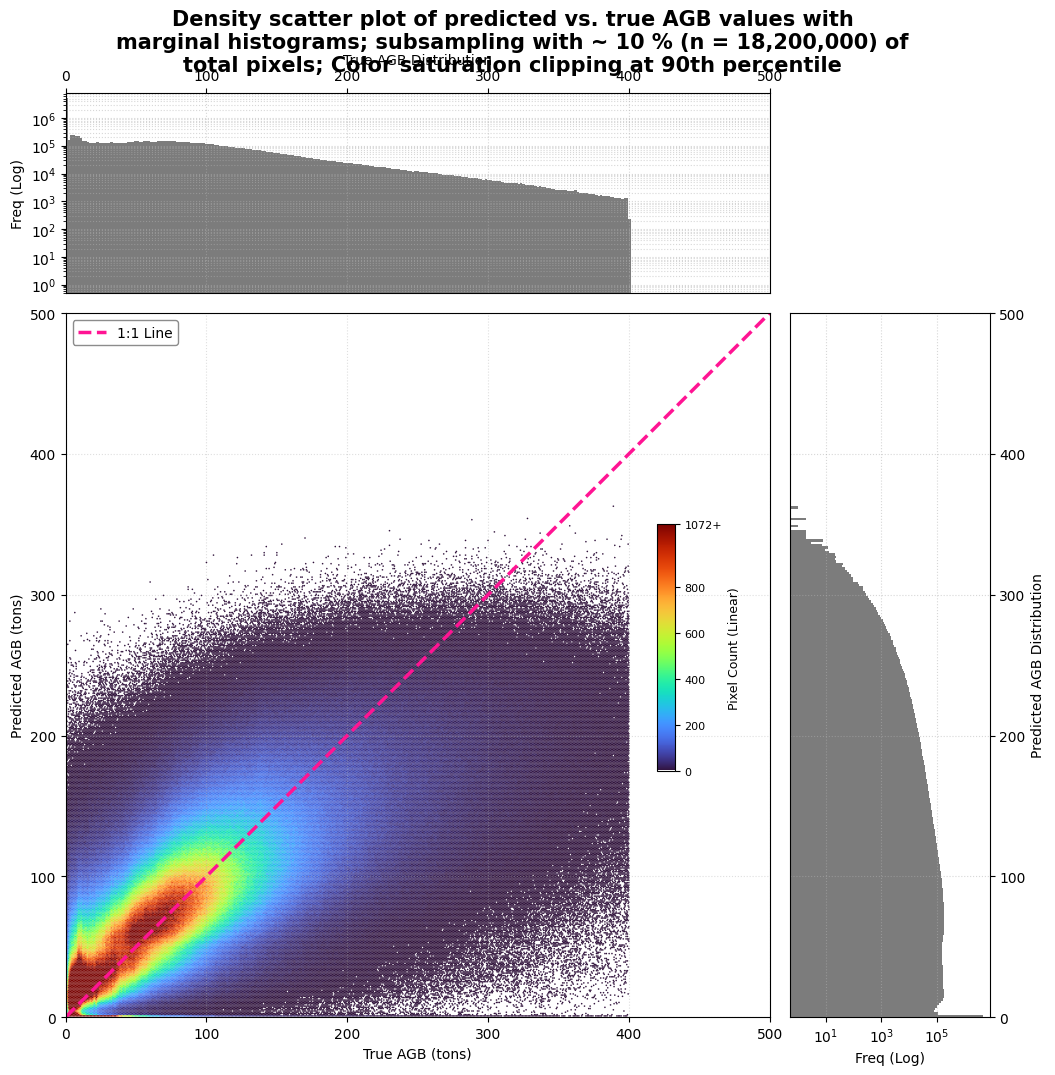

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.axes_size import Fixed
import numpy as np
import os
import textwrap

def plot_marginal_density(preds, targets, output_path,
                          title=None,
                          scale_type='power',
                          clip_percentile=99.0,
                          grid_res=150,
                          gamma_val=0.3,
                          cmap_name='turbo',
                          x_limit=None,
                          y_limit=None,
                          hist_size_inches=1.2,
                          title_wrap_width=50,
                          cbar_orient='horizontal',
                          cbar_tick_side='right'):

    if preds is None or targets is None: return

    print(f"Generating Marginal Density Plot ({scale_type} scale)...")

    plt.style.use('default')
    fig, ax_main = plt.subplots(figsize=(12, 12))

    if title:
        wrapped_title = "\n".join(textwrap.wrap(title, width=title_wrap_width))
        fig.suptitle(wrapped_title, fontsize=15, fontweight='bold', y=0.95)

    fig.subplots_adjust(top=0.88)

    # --- 1. Limits & Aspect ---
    data_max = max(targets.max(), preds.max())
    xmax = x_limit if x_limit is not None else data_max
    ymax = y_limit if y_limit is not None else data_max

    ax_main.set_aspect('equal')
    ax_main.set_xlim(0, xmax)
    ax_main.set_ylim(0, ymax)

    # --- 2. Create Axes ---
    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size=Fixed(hist_size_inches), pad=0.2, sharex=ax_main)
    ax_right = divider.append_axes("right", size=Fixed(hist_size_inches), pad=0.2, sharey=ax_main)

    # --- 3. Normalization ---
    if scale_type == 'log':
        norm_obj = LogNorm()
        scale_label = "Log"
        current_vmax = None
    elif scale_type == 'power':
        norm_obj = PowerNorm(gamma=gamma_val, vmin=1)
        scale_label = f"Power (g={gamma_val})"
        current_vmax = None
    else:
        norm_obj = Normalize(vmin=1)
        scale_label = "Linear"
        current_vmax = None

    # --- 4. Main Plot ---
    hb = ax_main.hexbin(
        targets, preds,
        gridsize=grid_res,
        cmap=cmap_name,
        mincnt=1,
        alpha=1.0,
        norm=norm_obj,
        linewidths=0.05,
        extent=[0, max(targets.max(), xmax), 0, max(preds.max(), ymax)]
    )

    if scale_type != 'log':
        counts = hb.get_array()
        if hasattr(counts, 'compressed'):
            counts = counts.compressed()
        if len(counts) > 0:
            current_vmax = np.percentile(counts, clip_percentile)
            hb.set_clim(vmin=1, vmax=current_vmax)

    # --- 5. Histograms ---
    bins_x = np.linspace(0, xmax, 300)
    bins_y = np.linspace(0, ymax, 300)

    hist_top_vals, _ = np.histogram(targets, bins=bins_x)
    hist_right_vals, _ = np.histogram(preds, bins=bins_y)
    max_freq = max(hist_top_vals.max(), hist_right_vals.max()) * 1.5
    min_freq = 0.5

    ax_top.hist(targets, bins=bins_x, color='#444444', alpha=0.7, log=True)
    ax_right.hist(preds, bins=bins_y, orientation='horizontal', color='#444444', alpha=0.7, log=True)

    ax_top.set_ylim(min_freq, max_freq)
    ax_right.set_xlim(min_freq, max_freq)
    ax_top.grid(True, linestyle=':', alpha=0.5, which='both')
    ax_right.grid(True, linestyle=':', alpha=0.5, which='both')

    # --- 6. Reference Line ---
    line_max = max(xmax, ymax)
    ax_main.plot([0, line_max], [0, line_max], color='#FF1493', linestyle='--', linewidth=2.5, label='1:1 Line')

    # --- 7. Formatting ---
    ax_main.set_xlabel('True AGB (tons)')
    ax_main.set_ylabel('Predicted AGB (tons)')
    ax_main.grid(True, linestyle=':', alpha=0.4)

    ax_top.tick_params(axis='x', which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax_top.set_xlabel('True AGB Distribution')
    ax_top.xaxis.set_label_position('top')
    ax_top.set_ylabel('Freq (Log)')

    ax_right.tick_params(axis='y', which='both', right=True, labelright=True, left=False, labelleft=False)
    ax_right.set_ylabel('Predicted AGB Distribution')
    ax_right.yaxis.set_label_position('right')
    ax_right.set_xlabel('Freq (Log)')

    # --- 8. Dynamic Layout Logic ---

    if cbar_orient == 'horizontal':
        # Horizontal Bar (Wide and Short)
        # Position: Top Right (0.65, 0.88), width 0.32
        cb_bounds = [0.65, 0.88, 0.32, 0.025]

        # Legend Position: Just below the bar
        legend_anchor = (0.98, 0.86)

        tick_position = 'bottom'
    else:
        # Vertical Bar (Tall and Narrow)
        # Position: Far Right Edge (0.94, 0.55), height 0.35
        cb_bounds = [0.94, 0.55, 0.025, 0.35]

        # Legend Position: To the LEFT of the bar's top
        legend_anchor = (0.92, 0.92)

        tick_position = 'right' # Ticks on the left side of vertical bar

        # Vertical Bar
        if cbar_tick_side == 'right':
            # SHIFT LEFT: If ticks are on the right, we must move the bar left
            # to make space for the text, otherwise it hits the histogram.
            # Moved x from 0.94 to 0.88
            cb_bounds = [0.84, 0.35, 0.025, 0.35]
        else:
            # If ticks are on the left, we can stay close to the edge
            cb_bounds = [0.94, 0.55, 0.025, 0.35]

        legend_anchor = (0.92, 0.92)

    # --- 9. Create Colorbar & Legend ---

    # Colorbar
    cb_ax = ax_main.inset_axes(cb_bounds)
    cb = plt.colorbar(hb, cax=cb_ax, orientation=cbar_orient)
    cb.set_label(f'Pixel Count ({scale_label})', fontsize=9)
    cb.outline.set_edgecolor('black')

    if cbar_orient == 'horizontal':
        cb.ax.xaxis.set_ticks_position(tick_position)
        cb.ax.xaxis.set_label_position(tick_position)
        cb.ax.xaxis.set_tick_params(color='black', labelcolor='black', labelsize=8)
    else:
        cb.ax.yaxis.set_ticks_position(tick_position)
        cb.ax.yaxis.set_label_position(tick_position)
        cb.ax.yaxis.set_tick_params(color='black', labelcolor='black', labelsize=8)

    # Force '+' Tick
    if scale_type != 'log' and current_vmax is not None:
        ticks = list(cb.get_ticks())
        ticks = [t for t in ticks if t < (current_vmax * 0.85)]
        ticks.append(current_vmax)
        labels = [f'{int(t)}' for t in ticks[:-1]]
        labels.append(f'{int(current_vmax)}+')
        cb.set_ticks(ticks)
        cb.set_ticklabels(labels)

    # Legend
    ax_main.legend(
        [ax_main.get_lines()[0]], ['1:1 Line'],
        loc='upper left',
        #bbox_to_anchor=legend_anchor,
        fontsize=10,
        frameon=True, facecolor='white', framealpha=0.9, edgecolor='gray'
    )

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---

if SCALE_CHOICE == 'linear':
  scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_hist_{SCALE_CHOICE}Scale_linClip{PLOT_LINEAR_CLIP_PERCENTILE}_xlim{x_limit}_ylimit{y_limit}_gridRes{GRID_RES}.png')
else:
  scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_hist_{SCALE_CHOICE}Scale_xlim{x_limit}_ylimit{y_limit}_gridRes{GRID_RES}.png')

plot_marginal_density(
    plot_preds,
    plot_targets,
    scatter_path,
    title=PLOT_TITLE,
    scale_type=SCALE_CHOICE,
    grid_res=GRID_RES,
    gamma_val=0.3,
    cmap_name='turbo',
    x_limit=500,
    y_limit=500,
    hist_size_inches=2.0,
    title_wrap_width=65,
    cbar_orient=CBAR_ORIENT, # <--- Try 'vertical' or 'horizontal'
    cbar_tick_side=CBAR_TICKSIDE  # Set to 'right' (Logic will now shift bar left to fix overlap)
)

Generating Marginal Density Plot (linear scale)...


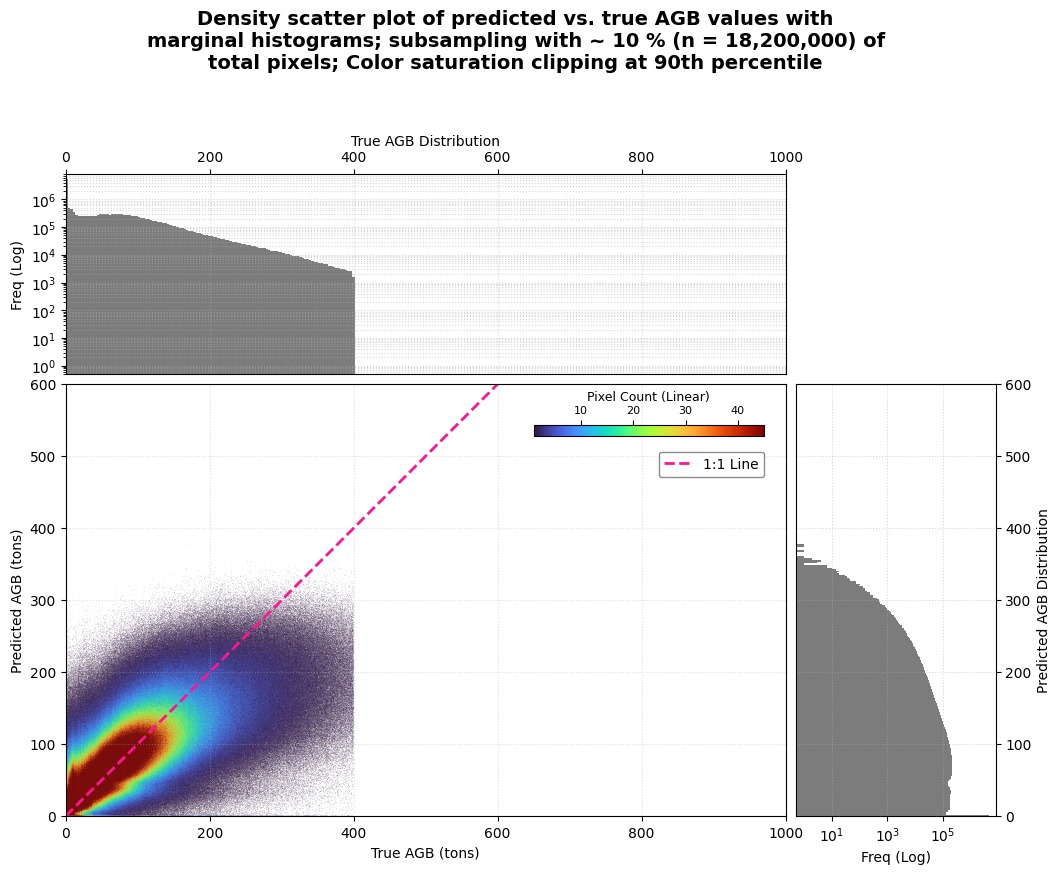

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, PowerNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.axes_size import Fixed
import numpy as np
import os
import textwrap

def plot_marginal_density(preds, targets, output_path,

                          title=None,
                          scale_type='power',
                          clip_percentile=99.0,
                          grid_res=150,
                          gamma_val=0.3,
                          cmap_name='turbo',
                          x_limit=None,
                          y_limit=None,
                          hist_size_inches=1.2,
                          title_wrap_width=50):

    if preds is None or targets is None: return

    print(f"Generating Marginal Density Plot ({scale_type} scale)...")

    plt.style.use('default')
    fig, ax_main = plt.subplots(figsize=(12, 12))

    # --- 1. Custom Title with Text Wrapping ---
    if title:
        wrapped_title = "\n".join(textwrap.wrap(title, width=title_wrap_width))
        # Lowered y from 0.98 to 0.93 to reduce the gap
        fig.suptitle(wrapped_title, fontsize=14, fontweight='bold', y=0.92)

    # --- 2. Adjust Subplot Layout (Crucial for Gap) ---
    # This pulls the plot area up closer to the title
    fig.subplots_adjust(top=0.92)

    # --- 3. Determine Limits ---
    data_max = max(targets.max(), preds.max())
    xmax = x_limit if x_limit is not None else data_max
    ymax = y_limit if y_limit is not None else data_max

    # --- 4. Enforce Aspect Ratio ---
    ax_main.set_aspect('equal')
    ax_main.set_xlim(0, xmax)
    ax_main.set_ylim(0, ymax)

    # --- 5. Create Attached Axes ---
    divider = make_axes_locatable(ax_main)
    ax_top = divider.append_axes("top", size=Fixed(hist_size_inches), pad=0.1, sharex=ax_main)
    ax_right = divider.append_axes("right", size=Fixed(hist_size_inches), pad=0.1, sharey=ax_main)

    # --- 6. Normalization ---
    if scale_type == 'log':
        norm_obj = LogNorm()
        scale_label = "Log"
    elif scale_type == 'power':
        norm_obj = PowerNorm(gamma=gamma_val, vmin=1)
        scale_label = f"Power (g={gamma_val})"
    else:
        norm_obj = Normalize(vmin=1)
        scale_label = "Linear"

    # --- 7. Main Scatter Plot ---
    hb = ax_main.hexbin(
        targets, preds,
        gridsize=grid_res,
        cmap=cmap_name,
        mincnt=1,
        alpha=1.0,
        norm=norm_obj,
        linewidths=0.05,
        extent=[0, max(targets.max(), xmax), 0, max(preds.max(), ymax)]
    )

    if scale_type != 'log':
        counts = hb.get_array()
        if hasattr(counts, 'compressed'):
            counts = counts.compressed()
        if len(counts) > 0:
            robust_vmax = np.percentile(counts, clip_percentile)
            hb.set_clim(vmin=1, vmax=robust_vmax)

    # --- 8. Marginal Histograms ---
    bins_x = np.linspace(0, xmax, 300)
    bins_y = np.linspace(0, ymax, 300)

    hist_top_vals, _ = np.histogram(targets, bins=bins_x)
    hist_right_vals, _ = np.histogram(preds, bins=bins_y)

    max_freq = max(hist_top_vals.max(), hist_right_vals.max()) * 1.5
    min_freq = 0.5

    ax_top.hist(targets, bins=bins_x, color='#444444', alpha=0.7, log=True)
    ax_right.hist(preds, bins=bins_y, orientation='horizontal', color='#444444', alpha=0.7, log=True)

    ax_top.set_ylim(min_freq, max_freq)
    ax_right.set_xlim(min_freq, max_freq)

    ax_top.grid(True, linestyle=':', alpha=0.5, which='both')
    ax_right.grid(True, linestyle=':', alpha=0.5, which='both')

    # --- 9. 1:1 Line ---
    line_max = max(xmax, ymax)
    ax_main.plot([0, line_max], [0, line_max], color='#FF1493', linestyle='--', linewidth=2.0, label='1:1 Line')

    # --- 10. Formatting ---
    ax_main.set_xlabel('True AGB (tons)')
    ax_main.set_ylabel('Predicted AGB (tons)')
    ax_main.grid(True, linestyle=':', alpha=0.4)

    # Top Labels
    ax_top.tick_params(axis='x', which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax_top.set_xlabel('True AGB Distribution')
    ax_top.xaxis.set_label_position('top')
    ax_top.set_ylabel('Freq (Log)')

    # Right Labels
    ax_right.tick_params(axis='y', which='both', right=True, labelright=True, left=False, labelleft=False)
    ax_right.set_ylabel('Predicted AGB Distribution')
    ax_right.yaxis.set_label_position('right')
    ax_right.set_xlabel('Freq (Log)')

    # --- 11. Legend & Colorbar ---

    # Colorbar
    cb_ax = ax_main.inset_axes([0.65, 0.88, 0.32, 0.025])
    cb = plt.colorbar(hb, cax=cb_ax, orientation='horizontal')
    cb.set_label(f'Pixel Count ({scale_label})', fontsize=9)
    cb.outline.set_edgecolor('black')
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top')
    cb.ax.xaxis.set_tick_params(color='black', labelcolor='black', labelsize=8)

    # Legend
    ax_main.legend(
        [ax_main.get_lines()[0]], ['1:1 Line'],
        loc='upper right',
        bbox_to_anchor=(0.98, 0.86),
        fontsize=10,
        frameon=True, facecolor='white', framealpha=0.9, edgecolor='gray'
    )

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---

if SCALE_CHOICE == 'linear':
  scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_hist_{SCALE_CHOICE}Scale_linClip{PLOT_LINEAR_CLIP_PERCENTILE}_xlim{x_limit}_ylimit{y_limit}_gridRes{grid_res}.png')
else:
  scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_hist_{SCALE_CHOICE}Scale_xlim{x_limit}_ylimit{y_limit}_gridRes{grid_res}.png')



# Define a very long title to test the wrapping
TITLE = f"Density scatter plot of predicted vs. true AGB values with marginal histograms; subsampling with ~ 10 % (n = 18,200,000) of total pixels; Color saturation clipping at {PLOT_LINEAR_CLIP_PERCENTILE}th percentile"

plot_marginal_density(
    plot_preds,
    plot_targets,
    scatter_path,
    title=TITLE,
    scale_type=SCALE_CHOICE,
    clip_percentile=PLOT_LINEAR_CLIP_PERCENTILE,
    grid_res=2500,
    gamma_val=0.3,
    cmap_name='turbo',
    x_limit=1000,
    y_limit=600,
    hist_size_inches=2.0,
    title_wrap_width=65
)

Generating Linear-Scale Density Scatter Plot...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


   -> Linear Scale: Clipped max color at bin_count=17 (Saturation > 70%)


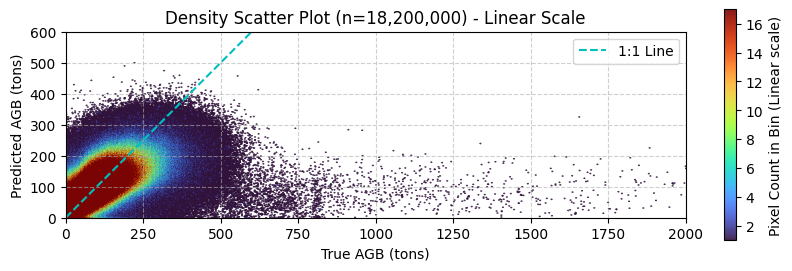

In [ ]:
scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_{scale_name}Scale_subsampl{PLOT_SAMPLE_SIZE}_clipSat{PLOT_LINEAR_CLIP_PERCENTILE}.png')
plot_density_scatter_from_data(
    plot_preds,
    plot_targets,
    scatter_path,
    log_scale=PLOT_LOG_SCALE,
    clip_percentile=PLOT_LINEAR_CLIP_PERCENTILE
)

In [ ]:
from matplotlib.colors import LogNorm, Normalize

# --- Updated Plotting Functions with Scale Toggle ---

def plot_density_scatter_from_data(preds, targets, output_path, log_scale=True):
    """
    Plots specific prediction/target arrays.
    Supports toggling between Log and Linear color scaling.
    """
    if preds is None or targets is None: return

    scale_str = "Log" if log_scale else "Linear"
    print(f"Generating {scale_str}-Scale Density Scatter Plot...")

    # Determine the Normalization object
    # LogNorm creates the log scale. None defaults to standard linear scaling.
    norm_obj = LogNorm() if log_scale else None

    plt.style.use('default')
    plt.figure(figsize=(10, 10))

    plt.hexbin(
        targets, preds, gridsize=80, cmap='inferno',
        mincnt=1, alpha=0.9,
        norm=norm_obj # <--- Applies the toggle
    )

    max_val = max(targets.max(), preds.max())
    plt.plot([0, max_val], [0, max_val], 'c--', label='1:1 Line')

    plt.colorbar(label=f'Pixel Count in Bin ({scale_str} Scale)')
    plt.xlabel('True AGB (tons)')
    plt.ylabel('Predicted AGB (tons)')
    plt.title(f'Density Scatter Plot (n={len(targets):,}) - {scale_str} Scale')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

Generating Log-Scale Density Scatter Plot...


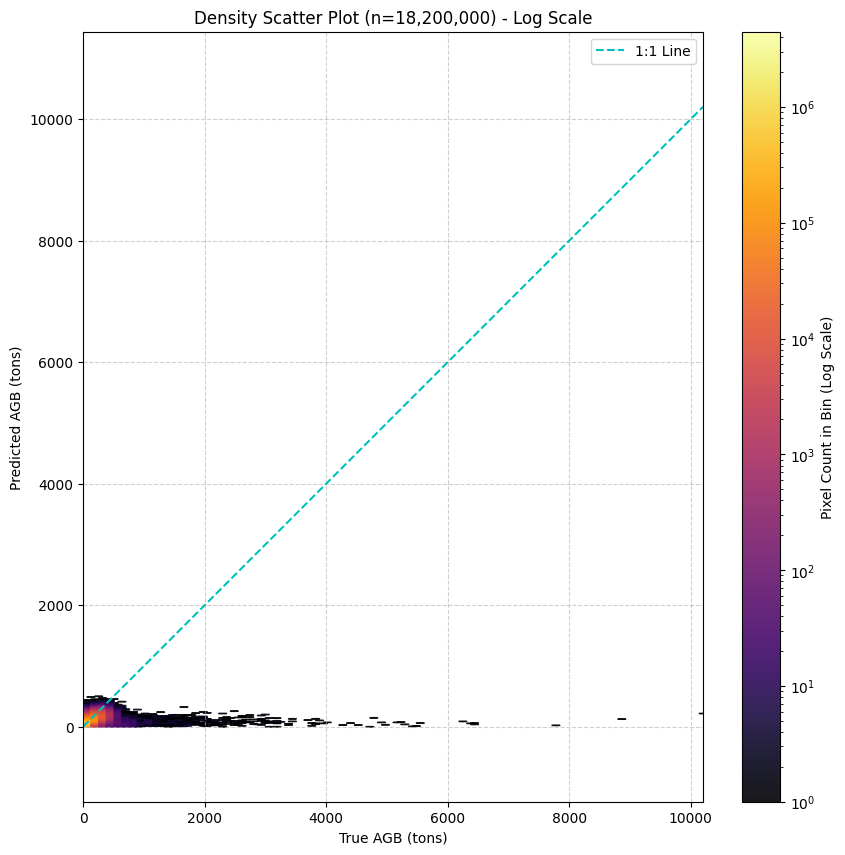

In [ ]:
# 1. Density Scatter Plot
scatter_path = os.path.join(config.OUTPUT_DIR, f'density_scatter_{scale_name}Scale_subsampl{PLOT_SAMPLE_SIZE}.png')
plot_density_scatter_from_data(
    plot_preds,
    plot_targets,
    scatter_path,
    log_scale=PLOT_LOG_SCALE
)

# Absolute Error vs. Target Scatter Plot

In [ ]:
def plot_error_vs_target_from_data(preds, targets, output_path, log_scale=True):
    """
    Plots Error vs Target using specific data arrays.
    Supports toggling between Log and Linear color scaling.
    """
    if preds is None or targets is None: return

    scale_str = "Log" if log_scale else "Linear"
    print(f"Generating {scale_str}-Scale Error vs. Target Plot...")

    absolute_errors = np.abs(preds - targets)

    norm_obj = LogNorm(vmin=1, vmax=None) if log_scale else None

    plt.style.use('default')
    plt.figure(figsize=(10, 8))

    plt.hexbin(
        targets,
        absolute_errors,
        gridsize=80,
        cmap='viridis',
        norm=norm_obj # <--- Applies the scale type toggle
    )

    plt.colorbar(label=f'Pixel Count in Bin ({scale_str} Scale)')
    plt.title(f'Absolute Error vs. True AGB (n={len(targets):,}) - {scale_str} Scale')
    plt.xlabel('True AGB (tons/pixel)')
    plt.ylabel('Absolute Error (tons/pixel)')
    plt.grid(True, which="both", ls="--", alpha=0.5)

    max_agb = targets.max()
    max_err = absolute_errors.max()
    plt.xlim(0, max_agb)
    plt.ylim(0, max_err)

    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

Generating Log-Scale Error vs. Target Plot...


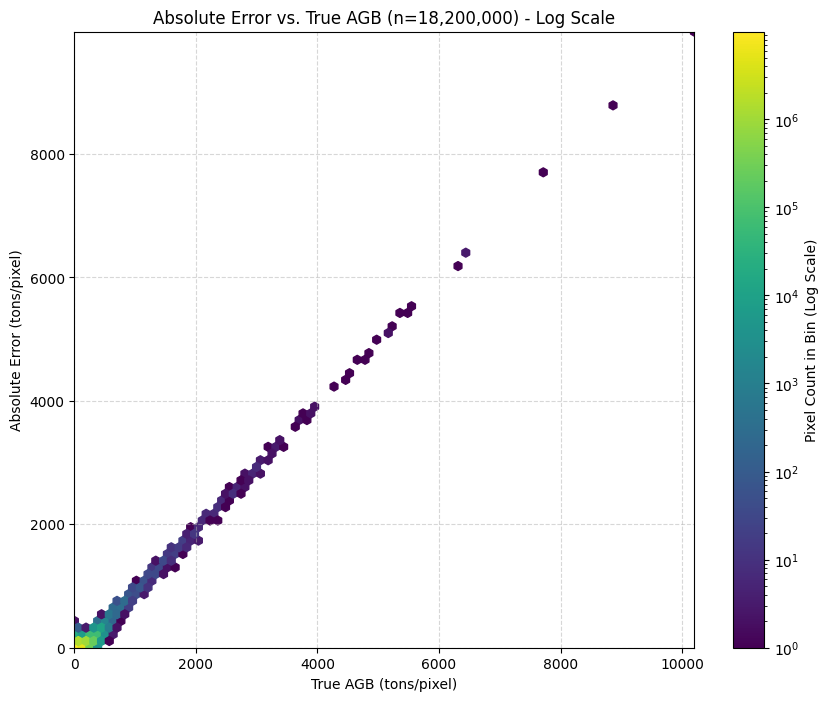

In [ ]:
error_scatter_path = os.path.join(config.OUTPUT_DIR, f'error_vs_target_scatter_{scale_name}Scale_subsampl{PLOT_SAMPLE_SIZE}.png')
plot_error_vs_target_from_data(
    plot_preds,
    plot_targets,
    error_scatter_path,
    log_scale=PLOT_LOG_SCALE
)

# Plotting Error Histogram

Loading best model from: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v6_WLR5.0-300.0_WLF10.0_EP50_BS16_LR0001_Seed42/best_model.pth
Starting error histogram generation on the test set...


Gathering data:   0%|          | 0/174 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Calculating errors...
Plotting histogram...


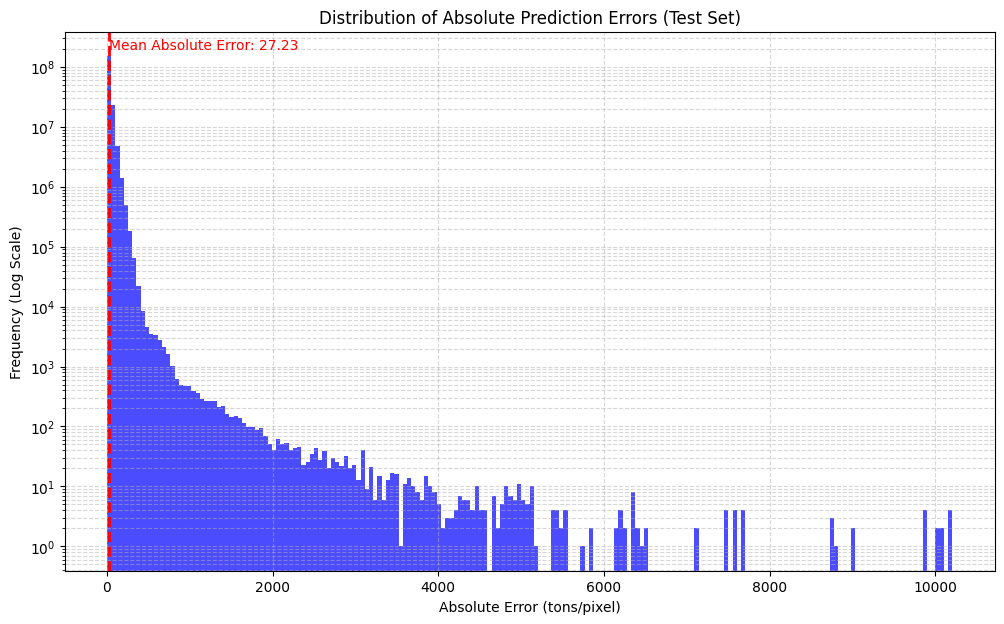

✅ Error histogram saved to: /content/drive/MyDrive/Colab_Notebooks/Training/baseline_models/UNet/UNet_v6_WLR5.0-300.0_WLF10.0_EP50_BS16_LR0001_Seed42/error_histogram.png


In [ ]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import torch
import numpy as np

# --- This cell loads the best model and generates an error histogram ---

def plot_error_histogram(loader, model, normalizer, device, output_dir):
    """
    Calculates the absolute pixel-wise errors and plots them as a histogram.
    """
    print("Starting error histogram generation on the test set...")
    model.eval()

    all_preds, all_targets = [], []

    # 1. Get all predictions and targets
    with torch.no_grad():
        for data, targets in tqdm(loader, desc="Gathering data"):
            data = data.to(device=device)
            data = normalizer(data)

            predictions = model(data)

            all_preds.append(predictions.cpu())
            all_targets.append(targets.cpu())

    print("Calculating errors...")
    all_preds = torch.cat(all_preds).view(-1)
    all_targets = torch.cat(all_targets).view(-1)

    # 2. Calculate the absolute deviation (error)
    absolute_errors = torch.abs(all_preds - all_targets).numpy()

    # 3. Plot the histogram
    print("Plotting histogram...")
    plt.figure(figsize=(12, 7))

    # We use a large number of bins for high resolution
    # and a log scale on the y-axis because most errors
    # will be small, creating a very skewed distribution.
    plt.hist(absolute_errors, bins=200, color='blue', alpha=0.7)

    plt.yscale('log') # Use log scale for frequency
    plt.title('Distribution of Absolute Prediction Errors (Test Set)')
    plt.xlabel('Absolute Error (tons/pixel)')
    plt.ylabel('Frequency (Log Scale)')
    plt.grid(True, which="both", ls="--", alpha=0.5)

    # Add a vertical line for the Mean Absolute Error (MAE)
    mae = np.mean(absolute_errors)
    plt.axvline(mae, color='red', linestyle='dashed', linewidth=2)
    plt.text(mae * 1.1, plt.ylim()[1] * 0.5, f'Mean Absolute Error: {mae:.2f}', color='red')

    # 4. Save the plot
    save_path = os.path.join(output_dir, 'error_histogram.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Error histogram saved to: {save_path}")

    del all_preds, all_targets, absolute_errors

# --- Main Execution Logic ---

# 1. Instantiate the model architecture
final_model = UNet(n_channels=2, n_classes=1, bilinear=False).to(config.DEVICE)

# 2. Load the weights of the best model
best_model_path = os.path.join(config.OUTPUT_DIR, 'best_model.pth')

if os.path.exists(best_model_path):
    print(f"Loading best model from: {best_model_path}")
    final_model.load_state_dict(torch.load(best_model_path, map_location=config.DEVICE))

    # 3. Generate and save the plot
    # This assumes 'test_loader' and 'normalize_transform' are available from previous cells
    plot_error_histogram(test_loader, final_model, normalize_transform, config.DEVICE, config.OUTPUT_DIR)

else:
    print(f"❌ Error: Best model file not found at '{best_model_path}'.")